In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import lime
import lime.lime_text
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

# Importing Dataset

In [2]:
x_train = pd.read_csv('X_train.csv')
x_test = pd.read_csv('X_test.csv')
x_val = pd.read_csv('X_val.csv')

In [3]:
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')
y_val = pd.read_csv('y_val.csv')

In [4]:
x_train.head()

,clean_tweet,tweet_length,num_hashtags,lexicon_score
0,watch video twice,79,1,0
1,lulu digital run yo ppc bernier dumb racist ps...,255,0,-2
2,freedumb clownvoy california afreedom convoya ...,116,0,0
3,dear toronto hereas expect afreedom convoya co...,136,0,0
4,trudeau state medium using illegally hacked da...,112,0,0


#  Converting y to 3 categories

In [5]:
def label_sentiment(score):
    if score in [0, 1]:  # e.g., most negative
        return 0  # Negative
    elif score == 2:     # neutral middle point
        return 1  # Neutral
    else:                # 3, 4 -> more positive
        return 2

y_train['y_class'] = y_train['label'].apply(label_sentiment)


In [6]:
y_test['y_class'] = y_test['label'].apply(label_sentiment)
y_val['y_class'] = y_val['label'].apply(label_sentiment)

In [7]:
y_train.nunique()

label      3
y_class    2
dtype: int64

In [8]:
print(y_train['label'].value_counts())
print(y_train['label'].unique())

label
2    178474
0     45939
1     40218
Name: count, dtype: int64
[1 0 2]


In [9]:

x_train['clean_tweet'] = x_train['clean_tweet'].fillna('').astype(str)
x_val['clean_tweet'] = x_val['clean_tweet'].fillna('').astype(str)
x_test['clean_tweet'] = x_test['clean_tweet'].fillna('').astype(str)

# Convert y_train, y_val, y_test to numpy arrays if they are DataFrames/Series

y_train_arr = y_train['y_class'].values
y_val_arr = y_val['y_class'].values
y_test_arr = y_test['y_class'].values

In [10]:
vocab_size = 10000 # Max number of words to keep based on frequency
embedding_dim = 100 # Dimension for the word embeddings
max_sequence_length = 100 # Max length for input sequencess

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
tokenizer.fit_on_texts(x_train['clean_tweet'])

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens after fitting on x_train.")

# Convert text to sequences and pad for all datasets
X_train_padded_text = pad_sequences(tokenizer.texts_to_sequences(x_train['clean_tweet']),
                                    maxlen=max_sequence_length, padding='post', truncating='post')
X_val_padded_text = pad_sequences(tokenizer.texts_to_sequences(x_val['clean_tweet']),
                                  maxlen=max_sequence_length, padding='post', truncating='post')
X_test_padded_text = pad_sequences(tokenizer.texts_to_sequences(x_test['clean_tweet']),
                                   maxlen=max_sequence_length, padding='post', truncating='post')

X_train_raw_text = x_train['clean_tweet'].values
X_val_raw_text = x_val['clean_tweet'].values
X_test_raw_text = x_test['clean_tweet'].values

Found 92636 unique tokens after fitting on x_train.


In [13]:
X_train_numerical = x_train[['tweet_length', 'num_hashtags', 'lexicon_score']].values
X_val_numerical = x_val[['tweet_length', 'num_hashtags', 'lexicon_score']].values
X_test_numerical = x_test[['tweet_length', 'num_hashtags', 'lexicon_score']].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_numerical_scaled = scaler.fit_transform(X_train_numerical)
X_val_numerical_scaled = scaler.transform(X_val_numerical)
X_test_numerical_scaled = scaler.transform(X_test_numerical)

In [14]:
num_classes = len(np.unique(y_train_arr)) 

In [15]:
print(num_classes)

2


In [ ]:
model_text_only = Sequential([
    Embedding(input_dim=10000, output_dim=100, input_length=100),
    Bidirectional(GRU(64, return_sequences=True)), # First GRU layer, returns sequences for next GRU
    Dropout(0.3),
    Bidirectional(GRU(32)), # Second GRU layer, returns a single vector
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # Softmax for multi-class classification
])

model_text_only.build(input_shape=(None, 100))
model_text_only.summary()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 100, 128)       │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,203 (4.19 MB)

 Trainable params: 1,099,203 (4.19 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_text_only.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#  Training model with early stopping 

In [22]:
start_time = time.time()
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Choose the model you want to train (model_text_only or model_multi_input)
# If using text-only model:
model_to_train = model_text_only
X_train_for_fit = X_train_padded_text
X_val_for_fit = X_val_padded_text



print("\nStarting model training...")
history = model_to_train.fit(
    X_train_for_fit, y_train_arr,
    epochs=5, # Set a reasonably high number of epochs; EarlyStopping will manage
    batch_size=32,
    validation_data=(X_val_for_fit, y_val_arr),
    callbacks=[early_stopping],
    verbose=1
)
print("Model training finished.")


Starting model training...
Epoch 1/5
8270/8270 ━━━━━━━━━━━━━━━━━━━━ 1933s 234ms/step - accuracy: 0.8739 - loss: 0.3172 - val_accuracy: 0.9052 - val_loss: 0.2484
Epoch 2/5
8270/8270 ━━━━━━━━━━━━━━━━━━━━ 1569s 190ms/step - accuracy: 0.9118 - loss: 0.2359 - val_accuracy: 0.9070 - val_loss: 0.2427
Epoch 3/5
8270/8270 ━━━━━━━━━━━━━━━━━━━━ 1647s 199ms/step - accuracy: 0.9240 - loss: 0.2068 - val_accuracy: 0.9063 - val_loss: 0.2492
Epoch 4/5
8270/8270 ━━━━━━━━━━━━━━━━━━━━ 1606s 194ms/step - accuracy: 0.9345 - loss: 0.1773 - val_accuracy: 0.9067 - val_loss: 0.2618
Epoch 5/5
8270/8270 ━━━━━━━━━━━━━━━━━━━━ 1546s 187ms/step - accuracy: 0.9474 - loss: 0.1462 - val_accuracy: 0.9040 - val_loss: 0.2865
Model training finished.


In [23]:
end_time = time.time()
training_time_seconds = end_time - start_time
print(f"Training Time = {training_time_seconds:.2f} seconds")

Training Time = 8301.48 seconds


In [24]:
model_to_train.save("gru_model.keras", save_format="keras")
print("Model saved successfully as gru_model.keras")

Model saved successfully as gru_model.keras


In [29]:
model_to_train.save("gru_model.h5")
print("Model saved successfully as gru_model.h5")

Model saved successfully as gru_model.h5


In [25]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved as tokenizer.pkl")

Tokenizer saved as tokenizer.pkl


In [36]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_sentiment, f)

print("Label encoder saved as label_encoder.pkl")

Label encoder saved as label_encoder.pkl


#  Test accuracy 

In [27]:
if model_to_train == model_text_only:
    X_test_for_eval = X_test_padded_text
else:
    X_test_for_eval = [X_test_padded_text, X_test_numerical_scaled]

loss, accuracy = model_to_train.evaluate(X_test_for_eval, y_test_arr, verbose=0)
print(f"\n--- Model Evaluation on Test Set ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


--- Model Evaluation on Test Set ---
Test Loss: 0.2416
Test Accuracy: 0.9077


2757/2757 ━━━━━━━━━━━━━━━━━━━━ 123s 44ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.82      0.85     28720
           1       0.92      0.95      0.93     59491

    accuracy                           0.91     88211
   macro avg       0.90      0.88      0.89     88211
weighted avg       0.91      0.91      0.91     88211


--- Confusion Matrix ---


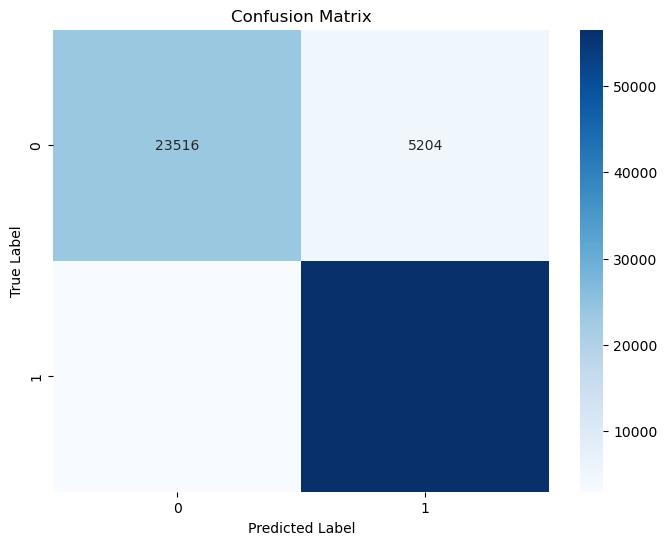

In [28]:
y_pred_probs = model_to_train.predict(X_test_for_eval)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_test_arr, y_pred_classes))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test_arr, y_pred_classes)
plt.figure(figsize=(8, 6))
# Ensure xticklabels and yticklabels match your actual class labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_train_arr), yticklabels=np.unique(y_train_arr))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [31]:
y_test_labels = np.argmax(y_test, axis=1)

In [32]:
y_pred_probs = model_to_train.predict(X_test_for_eval)

2757/2757 ━━━━━━━━━━━━━━━━━━━━ 150s 54ms/step


In [34]:
f1_macro = f1_score(y_test_labels, y_pred_classes, average='macro')
f1_micro = f1_score(y_test_labels, y_pred_classes, average='micro')
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Micro): {f1_micro:.4f}")

F1 Score (Macro): 0.2307
F1 Score (Micro): 0.2999


# LIME (feature importance)

In [43]:
# Function for LIME prediction (works for both text-only or multi-input models)
def predict_proba_for_lime(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')

    if model_to_train.name == 'model_multi_input':
        num_features_placeholder = np.zeros((len(texts), X_test_numerical_scaled.shape[1]))
        return model_to_train.predict([padded_sequences, num_features_placeholder])
    else:
        return model_to_train.predict(padded_sequences)

# Create LIME Explainer
explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=[str(c) for c in np.unique(y_train_arr)],
    split_expression=' ',
    random_state=42
)

# Index to explain
idx_to_explain = 0
text_to_explain = X_test_raw_text[idx_to_explain]
true_label = y_test_arr[idx_to_explain]

# Make prediction
if isinstance(X_test_for_eval, list):
    sample_input = [x[idx_to_explain:idx_to_explain+1] for x in X_test_for_eval]
else:
    sample_input = X_test_for_eval[idx_to_explain:idx_to_explain+1]

predicted_label_probs = model_to_train.predict(sample_input)
predicted_label_idx = np.argmax(predicted_label_probs, axis=1)[0]

# Display details
print(f"\n--- LIME Explanation for Test Sample at Index {idx_to_explain} ---")
print(f"Original Text: '{text_to_explain}'")
print(f"True Label: {true_label}")
print(f"Predicted Label: {predicted_label_idx}")

# Generate explanation
explanation_lime = explainer_lime.explain_instance(
    text_to_explain,
    predict_proba_for_lime,
    num_features=10,
    num_samples=1000
)

# Show important words
print("\nWord importance (LIME) for this prediction:")
for word, weight in explanation_lime.as_list():
    print(f"  '{word}': {weight:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

--- LIME Explanation for Test Sample at Index 0 ---
Original Text: 'every member parliament walked past protest every working day freedom convoy clearly danger parliament would shut'
True Label: 0
Predicted Label: 1
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step

Word importance (LIME) for this prediction:
  'freedom': 0.6048
  'clearly': 0.2417
  'protest': -0.1158
  'danger': -0.1033
  'convoy': 0.0688
  'every': 0.0355
  'parliament': 0.0263
  'would': -0.0220
  'past': -0.0184
  'walked': 0.0122
